# Wastewater viral loads

Covasim tracks each agent's viral load over time via a two-phase shedding model
controlled by `pars['viral_dist']` (`frac_time`, `load_ratio`, `high_cap`).
The full `pop_size × n_days` array is stored in `sim.people.viral_load`.

This tutorial covers:

1. **Basic access** — inspecting the raw viral load matrix.
2. **Multi-variant wastewater signal** — simulating wild-type, AY.1 and XBB.1.5
   introduced from consensus FASTA files, and plotting the wastewater viral load
   broken down by variant on both an absolute and a proportional y-axis.
3. **Amplicon sequencing with Bygul** — at the first day where all three variants
   co-circulate, invoking Bygul's `simulate_proportions` CLI to produce synthetic
   ARTIC V4.1 amplicon reads that reflect the simulated mixture proportions.

In [1]:
import covasim as cv

sim = cv.Sim(pop_size=2_000, pop_infected=5, n_days=60, verbose=0)
sim.run()

print('Viral load array shape:', sim.people.viral_load.shape,
      '  (rows = agents, columns = time-steps)')

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
Viral load array shape: (2000, 61)   (rows = agents, columns = time-steps)


## Multi-variant wastewater signal

We introduce two variants with `founding_fasta` files that set each variant's
characteristic mutation profile at the time of seeding.
`WastewaterSampler(group_by='variant')` aggregates each infectious agent's
instantaneous viral load by named variant rather than by full evolved haplotype,
producing a wastewater-like time-series.

> **Note:** FASTA files (`ay1_consensus.fasta`, `xbb15_consensus.fasta`,
> `NC_045512_Hu-1.fasta`) should be in the repository root.  Run the notebook
> from that directory, or update the path variables in the next cell.

In [2]:
import covasim as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Locate FASTA files and fitness data — assumed to live in the repository root
_cwd = Path(os.getcwd())
repo_root = _cwd if (_cwd / 'ay1_consensus.fasta').exists() else (_cwd / '../..').resolve()

ay1_fasta    = str(repo_root / 'ay1_consensus.fasta')
xbb15_fasta  = str(repo_root / 'xbb15_consensus.fasta')
ref_fasta    = str(repo_root / 'NC_045512_Hu-1.fasta')
fitness_path = str(repo_root / 'data' / 'nt_fitness.csv')

# Variants — rel_beta is NOT hard-coded.  fitness_pars (below) derives the
# transmission advantage from each variant's founding mutations by looking up
# every SNP in the Bloom lab nucleotide fitness landscape and computing
# rel_beta = exp(Σ log_fitness_i × scale).
ay1 = cv.variant(
    variant        = {},
    label          = 'AY.1',
    days           = 30,
    n_imports      = 50,
    founding_fasta = ay1_fasta,
)
xbb15 = cv.variant(
    variant        = {},
    label          = 'XBB.1.5',
    days           = 80,
    n_imports      = 50,
    founding_fasta = xbb15_fasta,
)

# WastewaterSampler in variant mode: sums viral load by named variant label.
# Sampling every day gives a continuous time-series.
ww = cv.WastewaterSampler(
    days     = list(range(0, 182)),
    group_by = 'variant',
    label    = 'WastewaterVariant',
)

# Second sampler in haplotype mode: captures each unique evolved sequence so
# simulate_sample() can feed the mixture to Bygul for amplicon-read synthesis.
# Sampled on a small set of candidate days only — haplotype reconstruction is
# O(n_infectious) and calling it every day would dominate runtime.
# Day ~100 is well after XBB.1.5's introduction (day 80) and before it sweeps,
# so all three variants are likely co-circulating there.
_haplotype_days = list(range(90, 131, 5))   # days 90, 95, 100 … 130
ww_h = cv.WastewaterSampler(
    days     = _haplotype_days,
    group_by = 'haplotype',
    label    = 'WastewaterHaplotype',
)

sim = cv.Sim(
    dict(
        pop_size     = 20_000,
        pop_infected = 20,
        start_day    = '2022-10-01',
        end_day      = '2023-04-01',
        seq_pars = dict(
            enable                = True,
            reference             = ref_fasta,
            rate_per_site_per_day = 0,
        ),
        fitness_pars = dict(
            enable       = True,
            model        = 'bloom_nt',      # Bloom lab nt_fitness.csv
            fitness_path = fitness_path,
            scale        = 0.05,             # multiplies log-fitness sum before exp()
        ),
    ),
    variants  = [ay1, xbb15],
    analyzers = [ww, ww_h],
    verbose   = 0,
)
sim.run()

/Users/dpilz/Desktop/covasim4wastewater/covasim/sequence_evolution.py:104: UserWarning: founding_fasta "/Users/dpilz/Desktop/covasim4wastewater/xbb15_consensus.fasta" length (29701) differs from reference (29903); aligning with biopython (indels ignored).
  warnings.warn(


Sim(<no label>; 2022-10-01 to 2023-04-01; pop: 20000 random; epi: 72782⚙, 197☠)

In [3]:
# Show the rel_beta multiplier that was derived from each variant's founding mutations.
# This makes the FASTA → fitness → transmissibility pathway explicit.
tracker       = sim.people.sequence_tracker
fitness_model = tracker.fitness_model

print(f'{"variant":12s}  {"founding SNPs":>13s}  {"rel_beta (×wt)":>15s}')
print('-' * 46)
# Wild-type carries no founding mutations → reference fitness = 1.0
for label, muts in [('wild', frozenset())] + list(tracker.variant_founding_mutations.items()):
    mult = fitness_model.compute_fitness(muts)
    print(f'{label:12s}  {len(muts):>13d}  {mult:>15.4f}')

variant       founding SNPs   rel_beta (×wt)
----------------------------------------------
wild                      0           1.0000
AY.1                     36           1.4507
XBB.1.5                 145          13.6734


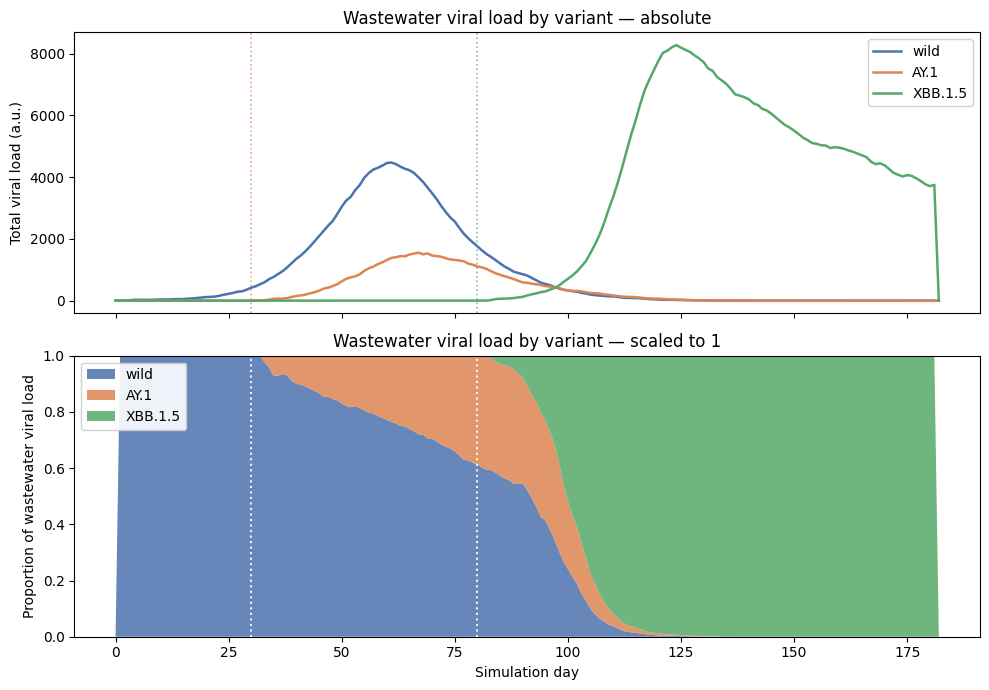

In [4]:
# Always use get_analyzer() — sim.analyzers[i] is a deep copy made at
# initialisation and contains no sampled data.
ww = sim.get_analyzer('WastewaterVariant')

variant_names = list(sim['variant_map'].values())   # e.g. ['wild', 'AY.1', 'XBB.1.5']
n_steps = sim.npts

# Build per-variant time series indexed by simulation step
loads = {v: np.zeros(n_steps) for v in variant_names}
props = {v: np.zeros(n_steps) for v in variant_names}

for day, sample in ww.samples.items():
    if sample is not None and day < n_steps:
        for vname, rl, p in zip(sample.variant_labels, sample.raw_loads, sample.proportions):
            loads[vname][day] = rl
            props[vname][day] = p

# Color palette (extend automatically for any extra variants)
palette = {'wild': '#4C72B0', 'AY.1': '#DD8452', 'XBB.1.5': '#55A868'}
_defaults = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, v in enumerate(variant_names):
    palette.setdefault(v, _defaults[i % len(_defaults)])

tvec       = np.arange(n_steps)
intro_days = {'AY.1': 30, 'XBB.1.5': 80}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# -- Absolute viral load signal -----------------------------------------------
for vname in variant_names:
    ax1.plot(tvec, loads[vname], label=vname, color=palette[vname], linewidth=1.8)
for vname, day in intro_days.items():
    ax1.axvline(day, color=palette[vname], linestyle=':', linewidth=1.2, alpha=0.7)
ax1.set_ylabel('Total viral load (a.u.)')
ax1.set_title('Wastewater viral load by variant — absolute')
ax1.legend(framealpha=0.9)

# -- Scaled to 1 (stacked area) -----------------------------------------------
stacked = np.array([props[v] for v in variant_names])
ax2.stackplot(tvec, stacked,
              labels=variant_names,
              colors=[palette[v] for v in variant_names],
              alpha=0.85)
for vname, day in intro_days.items():
    ax2.axvline(day, color='white', linestyle=':', linewidth=1.5, alpha=0.9)
ax2.set_xlabel('Simulation day')
ax2.set_ylabel('Proportion of wastewater viral load')
ax2.set_title('Wastewater viral load by variant — scaled to 1')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

## Amplicon sequencing snapshot with Bygul

`WastewaterSampler` in `group_by='haplotype'` mode records every unique evolved
sequence present in the infectious pool on each sampling day.  At a time-point
where wild-type, AY.1 and XBB.1.5 all co-circulate the mixture mirrors what a
real wastewater sequencing lab would see.

`simulate_sample()` writes each haplotype to a temporary FASTA file and calls
[Bygul](https://github.com/andersen-lab/Bygul)'s `simulate_proportions` CLI,
which tiles ARTIC V4.1 amplicons across each genome and produces synthetic
paired-end reads at the observed mixture proportions — giving a realistic
amplicon-sequencing dataset that reflects the simulated epidemiology.

> **Requires** the `bygul` package: `pip install bygul`  
> BED file `ARTIC_V4-1.bed` and reference `NC_045512_Hu-1.fasta` must be in
> the repository root (or update `bed_file` / `ref_fasta` below).

In [5]:
import glob, os, dataclasses

# From the candidate haplotype days, pick the first where all three variants
# each hold >1% of signal.  Fall back to day 100 if none qualifies.
ww_h = sim.get_analyzer('WastewaterHaplotype')
mixed_day = next(
    (t for t in sorted(ww_h.samples)
     if ww_h.samples[t] is not None
     and all(props[v][t] > 0.01 for v in ['wild', 'AY.1', 'XBB.1.5'])),
    100,
)

print(f'Sampling day {mixed_day}  ({sim.date(mixed_day)})')
print('  Variant-level proportions at that day:')
for v in ['wild', 'AY.1', 'XBB.1.5']:
    print(f'    {v:10s}  {props[v][mixed_day]:.1%}')

sample = ww_h.samples.get(mixed_day)
if sample is None:
    print('\nNo infectious agents were present on that day.')
else:
    print(f'\n  Unique haplotypes in pool : {sample.n_genotypes}')

    # Rank haplotypes by proportion and keep the top 5.
    # Renormalize so the subset proportions still sum to 1.0 — Bygul requires this.
    order     = sorted(range(sample.n_genotypes),
                       key=lambda i: sample.proportions[i], reverse=True)[:5]
    top_seqs  = [sample.sequences[i]   for i in order]
    top_loads = [sample.raw_loads[i]   for i in order]
    top_props = [sample.proportions[i] for i in order]
    total     = sum(top_props)
    top_props = [p / total for p in top_props]
    top_props[-1] = 1.0 - sum(top_props[:-1])   # absorb floating-point residual

    print(f'  Top-5 proportions (renormalized): {[round(p, 4) for p in top_props]}')
    print(f'  These cover {total:.1%} of the full pool by viral load')

    # Replace the stored sample with the trimmed version so simulate_sample() sees it
    ww_h.samples[mixed_day] = dataclasses.replace(
        sample,
        sequences   = top_seqs,
        proportions = top_props,
        raw_loads   = top_loads,
        n_genotypes = len(top_seqs),
    )

# Paths to required input files (already resolved earlier in the notebook)
bed_file = str(repo_root / 'ARTIC_V4-1.bed')
outdir   = './amplicon_reads/'

try:
    ww_h.simulate_sample(
        day             = mixed_day,
        primers         = bed_file,
        reference       = ref_fasta,
        outdir          = outdir,
        readcnt         = 300,
        redo            = True,
        simulation_mode = 'amplicon',
        seed            = 42,
    )
    fastq_files = (
        glob.glob(os.path.join(outdir, '**/*.fastq*'), recursive=True) +
        glob.glob(os.path.join(outdir, '*.fastq*'))
    )
    print(f'\nBygul wrote {len(fastq_files)} FASTQ file(s) to {outdir!r}:')
    for f in sorted(set(fastq_files))[:12]:
        print(f'  {os.path.relpath(f)}  ({os.path.getsize(f)/1024:.1f} kB)')
except ImportError as exc:
    print('\n[Bygul not installed — skipping read simulation]')
    print(str(exc))
    print('Install: pip install bygul   (https://github.com/andersen-lab/Bygul)')


Sampling day 90  (2022-12-30)
  Variant-level proportions at that day:
    wild        54.5%
    AY.1        37.6%
    XBB.1.5     7.8%

  Unique haplotypes in pool : 1
  Top-5 proportions (renormalized): [1.0]
  These cover 100.0% of the full pool by viral load
Directory './amplicon_reads/' exists. Removing andrecreating because --redo was set.

Genome: /var/folders/6f/j5htq5dj0jz5kmds0t7bf9fm0000gn/T/tmpd7184ty4/genotype_0.fasta
  Total ambiguous bases: 0
  Contig lengths:
    genotype_0: 29903
Reading and preprocessing the primer file...


Simulation progress...:   0%|          | 0/1 [00:00<?, ?it/s]

Processing sample genotype_0...
  Extracting ampliconsfrom contig: genotype_0...
Starting read simulation...


Simulation progress...: 100%|██████████| 1/1 [00:10<00:00, 10.07s/it]

Merging reads for genotype_0...
Finished all samples!

Bygul wrote 232 FASTQ file(s) to './amplicon_reads/':
  amplicon_reads/genotype_0/reads/amplicon_10_contig1_1.fastq  (24.4 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig1_2.fastq  (24.4 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig2_1.fastq  (24.4 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig2_2.fastq  (24.4 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig3_1.fastq  (24.4 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig3_2.fastq  (24.4 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig4_1.fastq  (24.4 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig4_2.fastq  (24.4 kB)
  amplicon_reads/genotype_0/reads/amplicon_11_contig1_1.fastq  (98.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_11_contig1_2.fastq  (98.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_12_contig1_1.fastq  (98.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_12_contig1_2.fastq  (98.0 kB)
